# Classificação de batimentos cardíacos com Deep Learning (MIT-BIH)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ljb6/ecg-ml/blob/main/notebooks/ecg_heartbeat.ipynb)

**Trabalho Final — M10 Deep Learning — Problema 6**

**Objetivo.** Uma clínica usa monitores Holter: são mais de 100 mil batimentos por exame de 24 h, e hoje um técnico revisa o traçado inteiro. Queremos **marcar os batimentos suspeitos** para que o técnico revise só esses. É uma **triagem, não um diagnóstico**: a decisão final é sempre humana.

**Roteiro do notebook**

1. Configuração e ambiente
2. Carregamento dos dados
3. Análise exploratória
4. Divisão treino/validação e desbalanceamento
5. Modelos: MLP (linha de base) e CNN 1D
6. Treinamento
7. Avaliação no conjunto de teste
8. Triagem: normal × suspeito
9. Investigação de vazamento entre treino e teste
10. Exemplos de previsões
11. Resumo, limitações e guia de modificações

**Como rodar.** No Colab: clique no botão acima e use *Ambiente de execução → Executar tudo*. Localmente: veja o `README.md` (Python 3.13 + venv).

## 1. Configuração e ambiente

Todas as decisões do experimento ficam no dicionário `CONFIG`. Para mudar o experimento, altere **só esta célula** e rode o notebook de novo.

> **Na defesa:** quase toda modificação ao vivo começa aqui (kernel, filtros, dropout, épocas, pesos das classes, limiar). Veja o guia de modificações na seção 11.

In [1]:
CONFIG = {
    # Reprodutibilidade
    "SEED": 42,

    # Dados
    "VAL_SIZE": 0.15,             # fração do treino separada para validação
    "PESO_CLASSES": "raiz",       # "raiz", "balanceado" ou "nenhum" (ver seção 4)

    # MLP (linha de base)
    "MLP_UNIDADES": [256, 128],   # neurônios de cada camada densa
    "MLP_DROPOUT": 0.3,

    # CNN 1D
    "CNN_FILTROS": [32, 64, 128, 128],  # filtros de cada bloco convolucional
    "CNN_KERNEL": 5,              # largura de cada filtro, em amostras (5 amostras = 40 ms)
    "CNN_DROPOUT": 0.3,

    # Treinamento
    "EPOCAS": 40,                 # máximo; o early stopping costuma parar antes
    "BATCH_SIZE": 256,
    "LEARNING_RATE": 1e-3,
    "PACIENCIA": 6,               # épocas sem melhora na validação antes de parar
    "TREINAR": True,              # False = carrega os modelos já treinados de results/models
    "MODO_RAPIDO": False,         # True = só 3 épocas (~1 min), para demonstrações ao vivo

    # Triagem
    "REVOCACAO_ALVO": 0.99,       # fração mínima dos batimentos anormais que o sistema deve marcar

    # Investigação de vazamento
    "N_AMOSTRAS_VAZAMENTO": 5000, # batimentos de teste usados na busca do vizinho mais próximo
}

A célula abaixo detecta se estamos no **Google Colab** ou em uma **máquina local** e monta os caminhos. No Colab, ela clona o repositório do grupo para ter a mesma estrutura de pastas (inclusive os modelos já treinados em `results/models`).

In [2]:
import sys
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/ljb6/ecg-ml"

try:
    import google.colab  # noqa: F401  (este módulo só existe dentro do Colab)
    NO_COLAB = True
except ImportError:
    NO_COLAB = False

if NO_COLAB:
    REPO_DIR = Path("/content/ecg-ml")
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", "-q", REPO_URL, str(REPO_DIR)], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U", "kagglehub"], check=True)
else:
    # Localmente o notebook é aberto de dentro da pasta notebooks/
    REPO_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_DIR = REPO_DIR / "data" / "heartbeat"
RESULTS_DIR = REPO_DIR / "results"
FIG_DIR = RESULTS_DIR / "figuras"
MODELS_DIR = RESULTS_DIR / "models"
for pasta in (DATA_DIR, FIG_DIR, MODELS_DIR):
    pasta.mkdir(parents=True, exist_ok=True)

print("Ambiente:", "Google Colab" if NO_COLAB else "local")
print("Pasta do projeto:", REPO_DIR)

Ambiente: local
Pasta do projeto: C:\Users\ResTIC55\projects\dev\GAIA\M10_DL\Trabalho-Final\ecg-ml


In [3]:
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score, recall_score,
)
from sklearn.neighbors import KNeighborsClassifier

# Fixa as sementes de Python, NumPy e TensorFlow para o resultado ser reproduzível
keras.utils.set_random_seed(CONFIG["SEED"])

MODO_RAPIDO = CONFIG["MODO_RAPIDO"]
SUFIXO = "_rapido" if MODO_RAPIDO else ""  # o modo rápido não sobrescreve os modelos oficiais

N_AMOSTRAS = 187                                  # pontos de cada batimento
FREQ_HZ = 125                                     # frequência de amostragem do sinal
TEMPO_MS = np.arange(N_AMOSTRAS) / FREQ_HZ * 1000  # eixo do tempo em milissegundos
CLASSES = ["N", "S", "V", "F", "Q"]               # rótulos 0 a 4, padrão AAMI
NOMES_CLASSES = {
    "N": "Normal",
    "S": "Supraventricular ectópico",
    "V": "Ventricular ectópico",
    "F": "Fusão",
    "Q": "Desconhecido / marcapasso",
}
N_CLASSES = len(CLASSES)

print("TensorFlow", tf.__version__, "| Keras", keras.__version__)
print("GPU disponível:", bool(tf.config.list_physical_devices("GPU")))

TensorFlow 2.21.0 | Keras 3.15.1


GPU disponível: False


## 2. Carregamento dos dados

Usamos os arquivos `mitbih_train.csv` e `mitbih_test.csv` do dataset [shayanfazeli/heartbeat](https://www.kaggle.com/datasets/shayanfazeli/heartbeat), derivado do [MIT-BIH Arrhythmia Database](https://physionet.org/content/mitdb/) (47 pacientes, gravados entre 1975 e 1979).

- Os CSVs **não têm cabeçalho**. Cada linha é um batimento: as 187 primeiras colunas são o sinal (~1,5 s a 125 Hz, já normalizado entre 0 e 1) e a última coluna é o rótulo (0 a 4).
- Os arquivos `ptbdb_*` do mesmo dataset (infarto, problema binário) **não** fazem parte deste trabalho.

Se os arquivos ainda não estiverem em `data/heartbeat/`, a célula baixa com `kagglehub`.

In [4]:
ARQ_TREINO = DATA_DIR / "mitbih_train.csv"
ARQ_TESTE = DATA_DIR / "mitbih_test.csv"

if not (ARQ_TREINO.exists() and ARQ_TESTE.exists()):
    try:
        import kagglehub
        print("Baixando o dataset do Kaggle (~100 MB)...")
        kagglehub.dataset_download("shayanfazeli/heartbeat", output_dir=str(DATA_DIR))
    except Exception as erro:
        raise RuntimeError(
            f"Não foi possível baixar o dataset ({erro}). Baixe mitbih_train.csv e "
            f"mitbih_test.csv manualmente do Kaggle e coloque em {DATA_DIR}"
        )

treino_df = pd.read_csv(ARQ_TREINO, header=None)
teste_df = pd.read_csv(ARQ_TESTE, header=None)

# 187 primeiras colunas = sinal; última coluna = rótulo
X_treino_total = treino_df.iloc[:, :-1].to_numpy(dtype="float32")
y_treino_total = treino_df.iloc[:, -1].to_numpy().astype(int)
X_teste = teste_df.iloc[:, :-1].to_numpy(dtype="float32")
y_teste = teste_df.iloc[:, -1].to_numpy().astype(int)

print("Treino:", X_treino_total.shape, "| Teste:", X_teste.shape)
print("Valores entre", X_treino_total.min(), "e", X_treino_total.max())
print("Valores ausentes:", int(treino_df.isna().sum().sum() + teste_df.isna().sum().sum()))

Treino: (87554, 187) | Teste: (21892, 187)
Valores entre 0.0 e 1.0
Valores ausentes: 0


## 3. Análise exploratória

### 3.1 Distribuição das classes

O ponto central do problema: a classe Normal domina. Por isso **acurácia não serve** como métrica principal.

,classe,treino,teste,% treino,% teste
0,N - Normal,72471,18118,82.77,82.76
1,S - Supraventricular ectópico,2223,556,2.54,2.54
2,V - Ventricular ectópico,5788,1448,6.61,6.61
3,F - Fusão,641,162,0.73,0.74
4,Q - Desconhecido / marcapasso,6431,1608,7.35,7.35


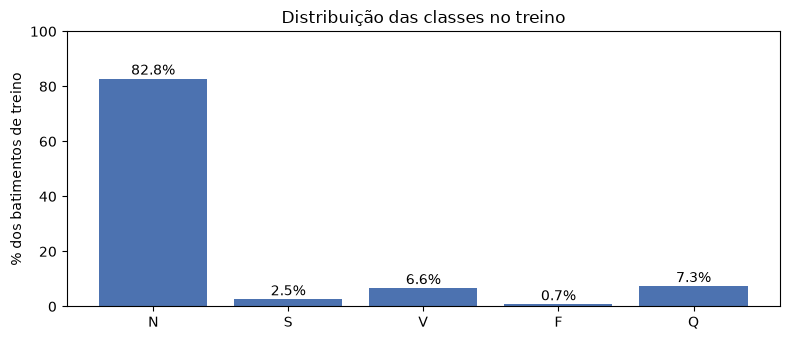

In [5]:
def contagem(y):
    return np.bincount(y, minlength=N_CLASSES)

dist = pd.DataFrame({
    "classe": [f"{c} - {NOMES_CLASSES[c]}" for c in CLASSES],
    "treino": contagem(y_treino_total),
    "teste": contagem(y_teste),
})
dist["% treino"] = (100 * dist["treino"] / dist["treino"].sum()).round(2)
dist["% teste"] = (100 * dist["teste"] / dist["teste"].sum()).round(2)
display(dist)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(CLASSES, dist["% treino"], color="#4C72B0")
for i, v in enumerate(dist["% treino"]):
    ax.text(i, v + 1.5, f"{v:.1f}%", ha="center")
ax.set_ylim(0, 100)
ax.set_ylabel("% dos batimentos de treino")
ax.set_title("Distribuição das classes no treino")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_distribuicao_classes.png", dpi=120)
plt.show()

**Linha de base trivial.** Um "modelo" que responde *Normal* para todo batimento já tem acurácia alta, mas não encontra nenhuma arritmia. Qualquer modelo nosso precisa ser comparado a isso usando métricas por classe.

In [6]:
pred_sempre_n = np.zeros_like(y_teste)
print(f"'Sempre Normal' no teste -> acurácia: {accuracy_score(y_teste, pred_sempre_n):.1%} | "
      f"macro-F1: {f1_score(y_teste, pred_sempre_n, average='macro', zero_division=0):.3f}")

'Sempre Normal' no teste -> acurácia: 82.8% | macro-F1: 0.181


### 3.2 Como é um batimento de cada classe

Em cinza, 10 batimentos sorteados de cada classe; em vermelho, o batimento médio. O pico no início é o complexo QRS (o recorte começa nele). Em muitos batimentos aparece um **segundo pico** mais adiante: é o QRS do **batimento seguinte**, e depois dele o sinal cai para os zeros do preenchimento.

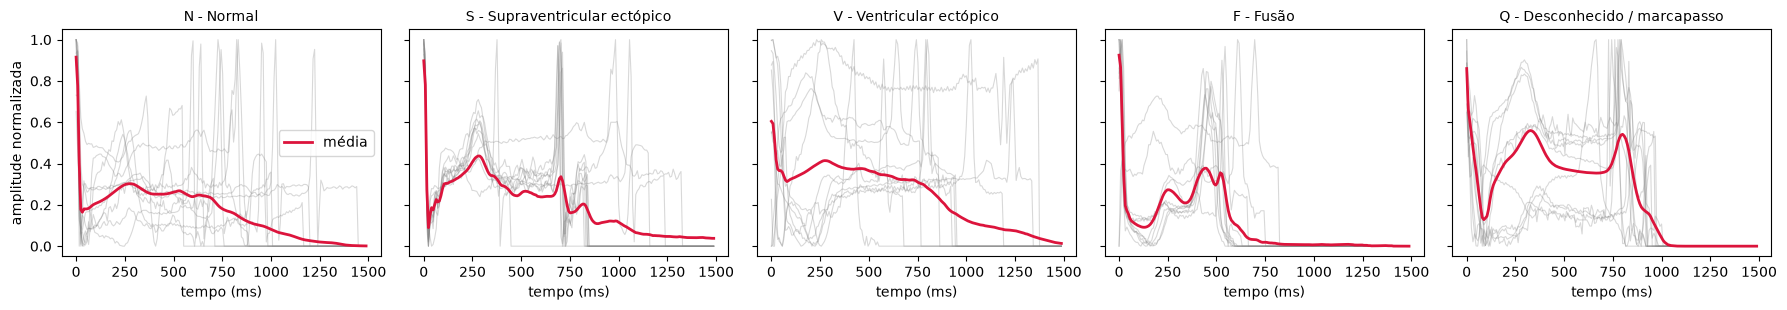

In [7]:
rng = np.random.default_rng(CONFIG["SEED"])
fig, axes = plt.subplots(1, N_CLASSES, figsize=(18, 3.2), sharey=True)
for c, ax in enumerate(axes):
    sinais = X_treino_total[y_treino_total == c]
    amostra = sinais[rng.choice(len(sinais), 10, replace=False)]
    ax.plot(TEMPO_MS, amostra.T, color="gray", alpha=0.3, lw=0.8)
    ax.plot(TEMPO_MS, sinais.mean(axis=0), color="crimson", lw=2, label="média")
    ax.set_title(f"{CLASSES[c]} - {NOMES_CLASSES[CLASSES[c]]}", fontsize=10)
    ax.set_xlabel("tempo (ms)")
axes[0].set_ylabel("amplitude normalizada")
axes[0].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "02_batimentos_por_classe.png", dpi=120)
plt.show()

### 3.3 Os zeros no final do sinal

Cada batimento foi recortado com 1,2 × o intervalo RR mediano da sua janela de 10 s e **completado com zeros** até 187 pontos. Então o **comprimento útil** (antes dos zeros) reflete o ritmo cardíaco: coração mais rápido → intervalo RR menor → comprimento útil menor.

> **Na defesa (professor):** o modelo pode usar esse comprimento como pista, e ele é clinicamente relevante. Mas o que define um batimento S é ser *prematuro* em relação aos vizinhos, e essa informação se perde em parte quando olhamos um batimento isolado. Isso ajuda a explicar por que S é a classe mais difícil.

,mean,25%,50%,75%
classe,,,,
N,886.0,744.0,848.0,1016.0
S,911.0,760.0,856.0,1080.0
V,945.0,760.0,912.0,1128.0
F,631.0,592.0,624.0,648.0
Q,946.0,928.0,960.0,984.0


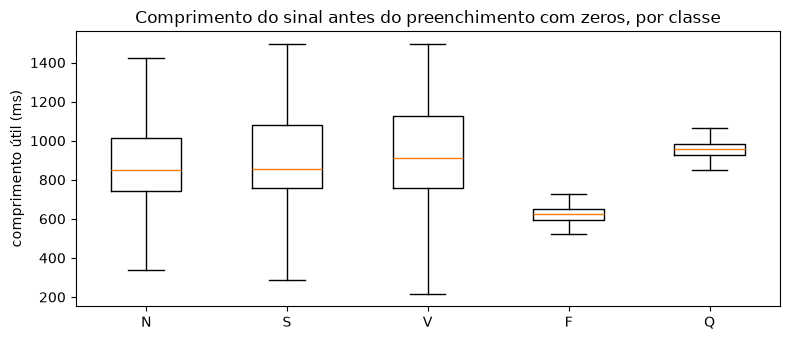

In [8]:
def comprimento_util(X):
    """Posição do último valor diferente de zero + 1 (o que vem depois é preenchimento)."""
    nao_zero = X != 0
    return N_AMOSTRAS - np.argmax(nao_zero[:, ::-1], axis=1)

comp_ms = comprimento_util(X_treino_total) / FREQ_HZ * 1000
df_comp = pd.DataFrame({"classe": [CLASSES[i] for i in y_treino_total], "comprimento útil (ms)": comp_ms})
display(df_comp.groupby("classe")["comprimento útil (ms)"].describe()[["mean", "25%", "50%", "75%"]]
        .reindex(CLASSES).round(0))

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.boxplot([comp_ms[y_treino_total == c] for c in range(N_CLASSES)], showfliers=False)
ax.set_xticks(range(1, N_CLASSES + 1), CLASSES)
ax.set_ylabel("comprimento útil (ms)")
ax.set_title("Comprimento do sinal antes do preenchimento com zeros, por classe")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_comprimento_util.png", dpi=120)
plt.show()

## 4. Divisão treino/validação e desbalanceamento

- O dataset já vem com teste separado. **O teste só é usado uma vez, na seção 7.** Todas as escolhas (early stopping, limiar da triagem) são feitas na **validação**.
- A validação sai de 15% do treino, **estratificada**: cada classe mantém a mesma proporção, garantindo exemplos das classes raras (F, S) na validação.
- Os rótulos viram **one-hot** (`2` → `[0, 0, 1, 0, 0]`), formato exigido pela perda `categorical_crossentropy` e pela métrica F1 do Keras.

In [9]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_treino_total, y_treino_total,
    test_size=CONFIG["VAL_SIZE"], stratify=y_treino_total, random_state=CONFIG["SEED"],
)

Y_tr = keras.utils.to_categorical(y_tr, N_CLASSES)
Y_val = keras.utils.to_categorical(y_val, N_CLASSES)

print(f"Treino: {len(X_tr)} | Validação: {len(X_val)} | Teste: {len(X_teste)}")

Treino: 74420 | Validação: 13134 | Teste: 21892


**Pesos das classes.** Com `class_weight`, errar um batimento de classe rara custa mais na função de perda. O peso **balanceado** de cada classe é

$$ w_c = \frac{n_{\text{total}}}{n_{\text{classes}} \times n_c} $$

Com ele, cada classe contribui com o mesmo peso total para a perda. Mas a classe F recebe peso ~27 e a N ~0,24: a correção é tão forte que o modelo passa a "ver" arritmia em batimentos normais, e o treino fica instável.

Por isso usamos a **raiz quadrada** do peso balanceado ($\sqrt{w_c}$): as classes raras continuam pesando mais, só que com menos exagero. A opção fica em `CONFIG["PESO_CLASSES"]`.

**Experimento que embasou a escolha.** Treinamos a CNN 1D com as três opções (mesma arquitetura, semente e callbacks) e escolhemos pela **macro-F1 na validação**, nunca pelo teste:

| Pesos de classe | Macro-F1 na validação (melhor época) | Comportamento do treino |
| --- | --- | --- |
| Balanceado | 0,808 | Instável; muitos normais classificados como S e F |
| Nenhum | 0,918 | Estável; revocação menor em S e F |
| **Raiz quadrada** | **0,925** | Estável; melhor equilíbrio entre as classes |

> **Na defesa (dev sênior):** escolhemos `class_weight` em vez de oversampling porque não cria dados artificiais e não aumenta o tempo de treino. E testamos três intensidades de peso em vez de aceitar o padrão "balanced" sem questionar.

In [10]:
pesos_balanceados = compute_class_weight("balanced", classes=np.arange(N_CLASSES), y=y_tr)
pesos = {
    "balanceado": pesos_balanceados,
    "raiz": np.sqrt(pesos_balanceados),
    "nenhum": np.ones(N_CLASSES),
}[CONFIG["PESO_CLASSES"]]
CLASS_WEIGHT = dict(enumerate(pesos))

display(pd.DataFrame({
    "classe": CLASSES,
    "exemplos no treino": contagem(y_tr),
    "peso balanceado": pesos_balanceados.round(2),
    f"peso em uso ({CONFIG['PESO_CLASSES']})": pesos.round(2),
}))

,classe,exemplos no treino,peso balanceado,peso em uso (raiz)
0,N,61600,0.24,0.49
1,S,1889,7.88,2.81
2,V,4920,3.03,1.74
3,F,545,27.31,5.23
4,Q,5466,2.72,1.65


## 5. Modelos

Os dois modelos recebem **exatamente a mesma entrada** (os 187 valores) e terminam com uma camada `softmax` de 5 saídas, que dá a probabilidade de cada classe.

### 5.1 MLP — linha de base

Trata os 187 pontos como **187 colunas independentes**. Cada neurônio da primeira camada tem um peso próprio para cada instante. A rede não sabe que o ponto 50 é vizinho do ponto 51: se embaralhássemos a ordem das colunas (a mesma ordem para todos os batimentos), a MLP aprenderia igual.

In [11]:
def construir_mlp():
    modelo = keras.Sequential(name="MLP")
    modelo.add(keras.Input(shape=(N_AMOSTRAS,)))
    for unidades in CONFIG["MLP_UNIDADES"]:
        modelo.add(layers.Dense(unidades, activation="relu"))
        modelo.add(layers.Dropout(CONFIG["MLP_DROPOUT"]))
    modelo.add(layers.Dense(N_CLASSES, activation="softmax"))
    return modelo

construir_mlp().summary()

Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        48,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,669 (319.02 KB)

 Trainable params: 81,669 (319.02 KB)

 Non-trainable params: 0 (0.00 B)

### 5.2 CNN 1D

Cada bloco convolucional faz:

1. **Conv1D:** filtros pequenos (5 amostras = 40 ms) deslizam pelo sinal procurando formas locais (subida do QRS, onda T...). O **mesmo filtro** é usado em todas as posições (*compartilhamento de pesos*), então uma forma é reconhecida onde quer que apareça, com muito menos parâmetros que a MLP.
2. **BatchNormalization:** normaliza as ativações de cada lote, o que estabiliza e acelera o treino.
3. **ReLU:** a não linearidade.
4. **MaxPooling1D(2):** reduz o sinal pela metade, mantendo o valor mais forte de cada par. Os blocos seguintes enxergam trechos cada vez maiores.

Depois dos blocos, **GlobalAveragePooling1D** tira a média de cada filtro ao longo do tempo (responde "quanto de cada padrão apareceu"), e camadas densas fazem a classificação.

> **Na defesa (professor):** o *campo receptivo* é o trecho do sinal original que um neurônio do último bloco "enxerga". A célula abaixo calcula esse valor para a configuração atual.

In [12]:
def construir_cnn():
    modelo = keras.Sequential(name="CNN_1D")
    modelo.add(keras.Input(shape=(N_AMOSTRAS,)))
    modelo.add(layers.Reshape((N_AMOSTRAS, 1)))  # Conv1D espera (tempo, canais); o ECG tem 1 canal
    for filtros in CONFIG["CNN_FILTROS"]:
        modelo.add(layers.Conv1D(filtros, CONFIG["CNN_KERNEL"], padding="same"))
        modelo.add(layers.BatchNormalization())
        modelo.add(layers.Activation("relu"))
        modelo.add(layers.MaxPooling1D(2))
    modelo.add(layers.GlobalAveragePooling1D())
    modelo.add(layers.Dropout(CONFIG["CNN_DROPOUT"]))
    modelo.add(layers.Dense(64, activation="relu"))
    modelo.add(layers.Dense(N_CLASSES, activation="softmax"))
    return modelo


def campo_receptivo(n_blocos, kernel, pool=2):
    """Quantas amostras do sinal original influenciam uma posição após n blocos Conv1D + MaxPool."""
    campo, salto = 1, 1
    for _ in range(n_blocos):
        campo += (kernel - 1) * salto  # convolução
        campo += (pool - 1) * salto    # max pooling
        salto *= pool
    return campo

cr = campo_receptivo(len(CONFIG["CNN_FILTROS"]), CONFIG["CNN_KERNEL"])
print(f"Campo receptivo do último bloco: {cr} amostras = {cr / FREQ_HZ * 1000:.0f} ms "
      f"(o batimento inteiro tem {N_AMOSTRAS} amostras = {N_AMOSTRAS / FREQ_HZ * 1000:.0f} ms)")
construir_cnn().summary()

Campo receptivo do último bloco: 76 amostras = 608 ms (o batimento inteiro tem 187 amostras = 1496 ms)


Model: "CNN_1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 187, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 187, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 187, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 187, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 93, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 93, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 93, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 93, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 46, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 46, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 46, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 46, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 23, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 23, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 11, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 143,621 (561.02 KB)

 Trainable params: 142,917 (558.27 KB)

 Non-trainable params: 704 (2.75 KB)

## 6. Treinamento

- **Otimizador:** Adam, com a taxa de aprendizado do `CONFIG`.
- **Perda:** entropia cruzada categórica, ponderada pelos pesos das classes.
- **Métrica monitorada:** **macro-F1 na validação** (a média simples do F1 das 5 classes). É a nossa métrica principal porque dá o mesmo peso a todas as classes.
- **Redução da taxa de aprendizado (`ReduceLROnPlateau`):** se a macro-F1 de validação não melhora por 2 épocas, a taxa de aprendizado cai pela metade. Passos menores ajudam o modelo a se acomodar perto de um bom mínimo.
- **Early stopping:** para quando a macro-F1 de validação não melhora por `PACIENCIA` épocas e **restaura os pesos da melhor época**.
- Os modelos treinados são salvos em `results/models/`. Com `TREINAR = False`, o notebook carrega esses arquivos em vez de treinar de novo.

In [13]:
def compilar(modelo):
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=CONFIG["LEARNING_RATE"]),
        loss="categorical_crossentropy",
        metrics=["accuracy", keras.metrics.F1Score(average="macro", name="f1_macro")],
    )


def treinar(construtor, nome):
    caminho_modelo = MODELS_DIR / f"{nome}{SUFIXO}.keras"
    caminho_hist = MODELS_DIR / f"{nome}{SUFIXO}_historico.json"

    if not CONFIG["TREINAR"]:
        print(f"Carregando {caminho_modelo.name} (TREINAR = False)")
        modelo = keras.models.load_model(caminho_modelo)
        return modelo, json.loads(caminho_hist.read_text())

    modelo = construtor()
    compilar(modelo)
    parada = keras.callbacks.EarlyStopping(
        monitor="val_f1_macro", mode="max",
        patience=CONFIG["PACIENCIA"], restore_best_weights=True,
    )
    reduz_lr = keras.callbacks.ReduceLROnPlateau(
        monitor="val_f1_macro", mode="max", factor=0.5, patience=2,
    )
    inicio = time.time()
    h = modelo.fit(
        X_tr, Y_tr,
        validation_data=(X_val, Y_val),
        epochs=3 if MODO_RAPIDO else CONFIG["EPOCAS"],
        batch_size=CONFIG["BATCH_SIZE"],
        class_weight=CLASS_WEIGHT,
        callbacks=[parada, reduz_lr],
        verbose=2,
    )
    print(f"{nome}: {len(h.history['loss'])} épocas em {time.time() - inicio:.0f} s")

    modelo.save(caminho_modelo)
    historico = {k: [float(v) for v in valores] for k, valores in h.history.items()}
    caminho_hist.write_text(json.dumps(historico, indent=1))
    return modelo, historico

In [14]:
mlp, hist_mlp = treinar(construir_mlp, "MLP")

Epoch 1/40


291/291 - 2s - 8ms/step - accuracy: 0.8871 - f1_macro: 0.5993 - loss: 0.4926 - val_accuracy: 0.9277 - val_f1_macro: 0.7306 - val_loss: 0.2628 - learning_rate: 0.0010


Epoch 2/40


291/291 - 1s - 5ms/step - accuracy: 0.9219 - f1_macro: 0.7146 - loss: 0.3155 - val_accuracy: 0.9398 - val_f1_macro: 0.7641 - val_loss: 0.2207 - learning_rate: 0.0010


Epoch 3/40


...

Epoch 32/40


291/291 - 1s - 3ms/step - accuracy: 0.9658 - f1_macro: 0.8493 - loss: 0.1356 - val_accuracy: 0.9703 - val_f1_macro: 0.8601 - val_loss: 0.1082 - learning_rate: 3.9063e-06


Epoch 33/40


291/291 - 1s - 3ms/step - accuracy: 0.9657 - f1_macro: 0.8483 - loss: 0.1353 - val_accuracy: 0.9703 - val_f1_macro: 0.8596 - val_loss: 0.1073 - learning_rate: 3.9063e-06


MLP: 33 épocas em 33 s


In [15]:
cnn, hist_cnn = treinar(construir_cnn, "CNN_1D")

Epoch 1/40


291/291 - 19s - 64ms/step - accuracy: 0.9300 - f1_macro: 0.7173 - loss: 0.3100 - val_accuracy: 0.0661 - val_f1_macro: 0.0248 - val_loss: 4.9889 - learning_rate: 0.0010


Epoch 2/40


291/291 - 21s - 72ms/step - accuracy: 0.9544 - f1_macro: 0.8051 - loss: 0.1897 - val_accuracy: 0.2758 - val_f1_macro: 0.2483 - val_loss: 1.8901 - learning_rate: 0.0010


Epoch 3/40


...

Epoch 30/40


291/291 - 24s - 81ms/step - accuracy: 0.9906 - f1_macro: 0.9589 - loss: 0.0280 - val_accuracy: 0.9845 - val_f1_macro: 0.9149 - val_loss: 0.0569 - learning_rate: 3.9063e-06


Epoch 31/40


291/291 - 25s - 85ms/step - accuracy: 0.9911 - f1_macro: 0.9595 - loss: 0.0273 - val_accuracy: 0.9848 - val_f1_macro: 0.9169 - val_loss: 0.0565 - learning_rate: 3.9063e-06


CNN_1D: 31 épocas em 694 s


### Curvas de treino

Atenção ao ler a curva de **perda**: com `class_weight`, a perda de treino é ponderada e a de validação não é, então as duas não estão na mesma escala. Para comparar treino e validação, use a curva de **macro-F1**.

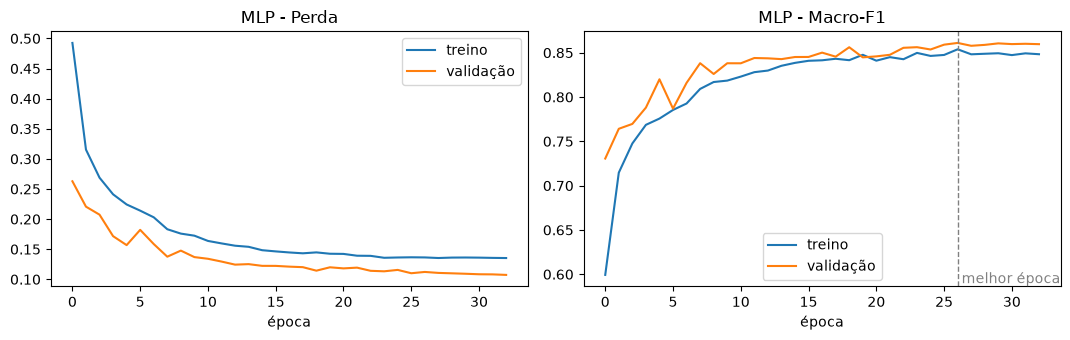

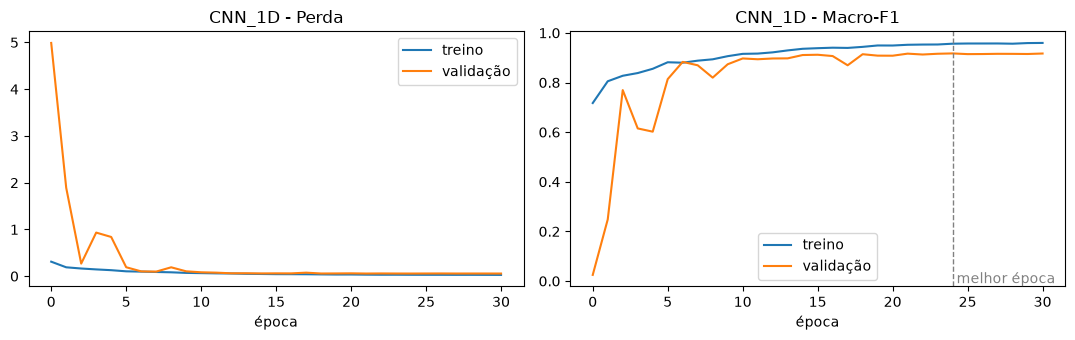

In [16]:
def plotar_curvas(historico, nome):
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    for ax, metrica, titulo in zip(axes, ["loss", "f1_macro"], ["Perda", "Macro-F1"]):
        ax.plot(historico[metrica], label="treino")
        ax.plot(historico["val_" + metrica], label="validação")
        ax.set_title(f"{nome} - {titulo}")
        ax.set_xlabel("época")
        ax.legend()
    melhor = int(np.argmax(historico["val_f1_macro"]))
    axes[1].axvline(melhor, color="gray", ls="--", lw=1)
    axes[1].text(melhor, axes[1].get_ylim()[0], " melhor época", color="gray", va="bottom")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"04_curvas_{nome}{SUFIXO}.png", dpi=120)
    plt.show()

plotar_curvas(hist_mlp, "MLP")
plotar_curvas(hist_cnn, "CNN_1D")

## 7. Avaliação no conjunto de teste

Aqui usamos o teste **pela primeira e única vez**. Para cada batimento, a classe prevista é a de maior probabilidade (`argmax`).

- **Precisão** de uma classe: dos batimentos que o modelo chamou de X, quantos eram X.
- **Revocação (recall)** de uma classe: dos batimentos que eram X, quantos o modelo encontrou.
- **F1:** média harmônica de precisão e revocação.
- **Macro-F1:** média simples do F1 das 5 classes (nossa métrica principal).

In [17]:
resultados = {}
for nome, modelo in [("MLP", mlp), ("CNN_1D", cnn)]:
    probs = modelo.predict(X_teste, batch_size=1024, verbose=0)
    resultados[nome] = {"probs": probs, "pred": probs.argmax(axis=1)}
    print(f"===== {nome} =====")
    print(classification_report(y_teste, resultados[nome]["pred"], target_names=CLASSES, digits=3, zero_division=0))

===== MLP =====
              precision    recall  f1-score   support

           N      0.985     0.982     0.983     18118
           S      0.741     0.709     0.724       556
           V      0.904     0.919     0.911      1448
           F      0.591     0.802     0.681       162
           Q      0.973     0.971     0.972      1608

    accuracy                          0.969     21892
   macro avg      0.839     0.877     0.854     21892
weighted avg      0.970     0.969     0.969     21892



===== CNN_1D =====
              precision    recall  f1-score   support

           N      0.991     0.993     0.992     18118
           S      0.860     0.797     0.827       556
           V      0.962     0.956     0.959      1448
           F      0.747     0.858     0.799       162
           Q      0.993     0.991     0.992      1608

    accuracy                          0.984     21892
   macro avg      0.911     0.919     0.914     21892
weighted avg      0.984     0.984     0.984     21892



In [18]:
def resumo_metricas(y_true, y_pred):
    revocacoes = recall_score(y_true, y_pred, labels=range(N_CLASSES), average=None, zero_division=0)
    resumo = {
        "acurácia": accuracy_score(y_true, y_pred),
        "acurácia balanceada": balanced_accuracy_score(y_true, y_pred),
        "macro-F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }
    resumo.update({f"revocação {c}": r for c, r in zip(CLASSES, revocacoes)})
    return resumo

tabela = pd.DataFrame({
    "Sempre Normal": resumo_metricas(y_teste, pred_sempre_n),
    **{nome: resumo_metricas(y_teste, r["pred"]) for nome, r in resultados.items()},
}).T.round(3)
display(tabela)

,acurácia,acurácia balanceada,macro-F1,revocação N,revocação S,revocação V,revocação F,revocação Q
Sempre Normal,0.828,0.200,0.181,1.000,0.000,0.000,0.000,0.000
MLP,0.969,0.877,0.854,0.982,0.709,0.919,0.802,0.971
CNN_1D,0.984,0.919,0.914,0.993,0.797,0.956,0.858,0.991


### Matrizes de confusão

Cada linha é a classe **real** e cada coluna a classe **prevista**. Os valores estão normalizados por linha: a diagonal é a revocação de cada classe, e fora dela vemos com quem cada classe é confundida.

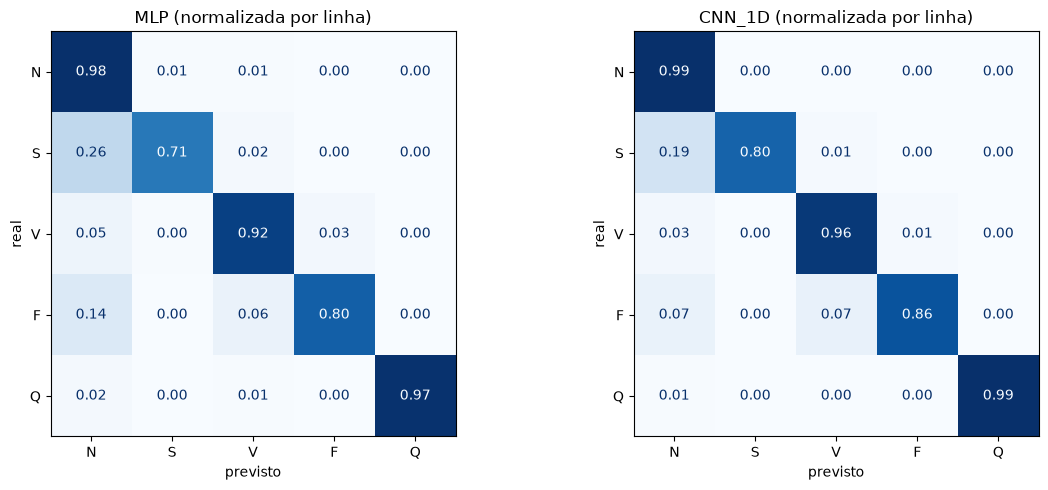

CNN 1D - contagens absolutas (linhas = real, colunas = previsto):


,N,S,V,F,Q
N,17987,67,32,24,8
S,103,443,8,1,1
V,37,3,1384,21,3
F,11,0,12,139,0
Q,9,2,3,1,1593


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (nome, r) in zip(axes, resultados.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_teste, r["pred"], display_labels=CLASSES, normalize="true",
        values_format=".2f", cmap="Blues", colorbar=False, ax=ax,
    )
    ax.set_title(f"{nome} (normalizada por linha)")
    ax.set_xlabel("previsto")
    ax.set_ylabel("real")
plt.tight_layout()
plt.savefig(FIG_DIR / f"05_matrizes_confusao{SUFIXO}.png", dpi=120)
plt.show()

print("CNN 1D - contagens absolutas (linhas = real, colunas = previsto):")
display(pd.DataFrame(confusion_matrix(y_teste, resultados["CNN_1D"]["pred"]), index=CLASSES, columns=CLASSES))

### 7.1 E se usássemos uma RNN?

O enunciado sugere CNN 1D **ou** RNN. Testamos três variantes de GRU **fora do notebook** (script `experimentos/exp_rnn.py`), com a mesma divisão, os mesmos pesos de classe e os mesmos callbacks. A decisão é pela macro-F1 na **validação**; o teste aparece só como referência.

| Modelo | Parâmetros | Tempo por época (CPU) | Macro-F1 validação | Macro-F1 teste |
| --- | --- | --- | --- | --- |
| GRU, lendo na ordem normal | 17.349 | ~59 s | 0,792 | 0,773 |
| GRU, lendo de trás para frente | 17.349 | ~57 s | 0,814 | 0,808 |
| MLP (este notebook) | 81.669 | ~1 s | 0,861 | 0,854 |
| CNN + GRU (2 blocos convolucionais e depois a GRU) | 40.325 | ~26 s | 0,870 | 0,865 |
| **CNN 1D (este notebook)** | 143.621 | ~22 s | **0,917** | **0,914** |

**Por que a RNN ficou para trás aqui**

- O que diferencia as classes é a **forma local** do batimento (QRS, ondas P e T). Filtros convolucionais são feitos para isso; a RNN lê as 187 amostras uma a uma e precisa guardar tudo numa memória.
- **Lentidão:** a RNN processa o tempo em sequência e não paraleliza. Cada época leva ~2,5 vezes o tempo da CNN, com um modelo 8 vezes menor.
- **Zeros do preenchimento:** na ordem normal, a GRU lê dezenas de zeros depois do batimento antes de decidir, e a memória se apaga. Lendo de trás para frente (zeros primeiro, QRS por último), ela melhora de 0,792 para 0,814.
- O **híbrido** melhora porque a convolução extrai as formas e encurta a sequência de 187 para 46 passos, mas ainda fica abaixo da CNN pura.

**Ressalvas honestas:** usamos uma GRU pequena (64 unidades), e a versão de trás para frente parou no limite de 40 épocas ainda melhorando devagar. Uma LSTM maior ou bidirecional poderia chegar mais perto da CNN, mas com custo de treino várias vezes maior. Por isso ficamos com a CNN 1D.

> **Na defesa (professor):** "Por que não uma RNN?" → mostrar esta tabela e os motivos acima.

## 8. Triagem: normal × suspeito

Para a clínica, a pergunta prática é: **quais batimentos o técnico precisa revisar?** Então juntamos as quatro classes anormais em "suspeito" e usamos

$$ \text{suspeita} = 1 - P(\text{Normal}) $$

Um batimento é marcado quando a suspeita passa de um **limiar**. Limiar baixo marca mais batimentos (o técnico trabalha mais, mas perde menos arritmias); limiar alto marca menos.

O limiar é escolhido **na validação**: o maior valor que ainda marca pelo menos `REVOCACAO_ALVO` dos batimentos anormais. Depois medimos o resultado no teste.

> **Na defesa (cliente e risco):** um falso negativo (arritmia não marcada) é muito pior que um falso positivo (o técnico olha um batimento normal a mais). Por isso fixamos a revocação alta e aceitamos revisar mais batimentos.

In [20]:
def curva_triagem(probs, y, limiares=np.linspace(0, 1, 1001)):
    """Para cada limiar: fração de batimentos marcados e fração dos anormais que foram marcados."""
    suspeita = 1 - probs[:, 0]
    anormal = y != 0
    marcados = np.array([(suspeita >= t).mean() for t in limiares])
    revocacao = np.array([(suspeita[anormal] >= t).mean() for t in limiares])
    return limiares, marcados, revocacao

# Escolha do limiar na VALIDAÇÃO
probs_val = cnn.predict(X_val, batch_size=1024, verbose=0)
limiares, _, rec_val = curva_triagem(probs_val, y_val)
LIMIAR = float(limiares[rec_val >= CONFIG["REVOCACAO_ALVO"]].max())
print(f"Limiar escolhido na validação: {LIMIAR:.3f}")

# Resultado no TESTE
suspeita_teste = 1 - resultados["CNN_1D"]["probs"][:, 0]
marcado = suspeita_teste >= LIMIAR
anormal = y_teste != 0
triagem = {
    "limiar": LIMIAR,
    "fração revisada": float(marcado.mean()),
    "revocação dos anormais": float(marcado[anormal].mean()),
    "precisão (marcados que eram anormais)": float(anormal[marcado].mean()),
    **{f"revocação {CLASSES[c]}": float(marcado[y_teste == c].mean()) for c in range(1, N_CLASSES)},
}
display(pd.Series(triagem).round(4).to_frame("CNN 1D no teste"))

def milhar(n):
    """Formata 12345.6 como '12.346' (separador de milhar brasileiro)."""
    return f"{n:,.0f}".replace(",", ".")

por_exame = 100_000
revisados = triagem["fração revisada"] * por_exame
perdidos = (1 - triagem["revocação dos anormais"]) * anormal.mean() * por_exame
print(f"\nEm um exame de {milhar(por_exame)} batimentos com a mesma proporção do teste:")
print(f"  - o técnico revisaria cerca de {milhar(revisados)} batimentos "
      f"({triagem['fração revisada']:.1%}) em vez de todos;")
print(f"  - ficariam sem marcação cerca de {milhar(perdidos)} batimentos anormais "
      f"({1 - triagem['revocação dos anormais']:.1%} dos anormais).")

Limiar escolhido na validação: 0.015


,CNN 1D no teste
limiar,0.0150
fração revisada,0.2550
revocação dos anormais,0.9857
precisão (marcados que eram anormais),0.6663
revocação S,0.9299
revocação V,0.9945
revocação F,0.9877
revocação Q,0.9969



Em um exame de 100.000 batimentos com a mesma proporção do teste:
  - o técnico revisaria cerca de 25.502 batimentos (25.5%) em vez de todos;
  - ficariam sem marcação cerca de 247 batimentos anormais (1.4% dos anormais).


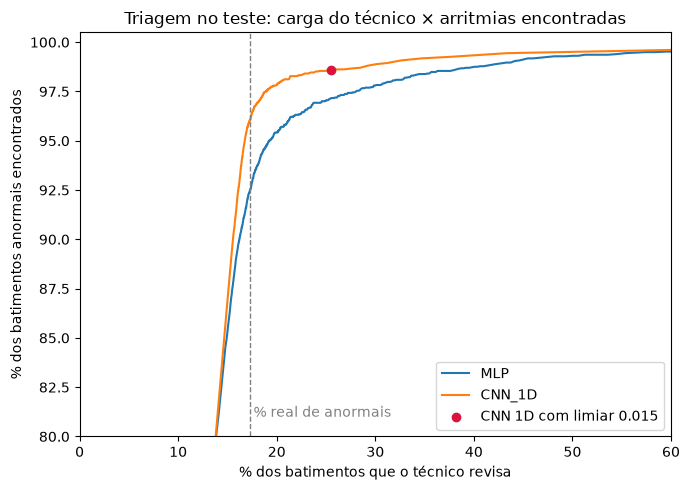

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
for nome, r in resultados.items():
    _, marcados, revocacao = curva_triagem(r["probs"], y_teste)
    ax.plot(100 * marcados, 100 * revocacao, label=nome)
ax.scatter(100 * triagem["fração revisada"], 100 * triagem["revocação dos anormais"],
           color="crimson", zorder=3, label=f"CNN 1D com limiar {LIMIAR:.3f}")
ax.axvline(100 * anormal.mean(), color="gray", ls="--", lw=1)
ax.text(100 * anormal.mean(), 81, " % real de anormais", color="gray")
ax.set_xlim(0, 60)
ax.set_ylim(80, 100.5)
ax.set_xlabel("% dos batimentos que o técnico revisa")
ax.set_ylabel("% dos batimentos anormais encontrados")
ax.set_title("Triagem no teste: carga do técnico × arritmias encontradas")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / f"06_triagem{SUFIXO}.png", dpi=120)
plt.show()

## 9. Investigação de vazamento entre treino e teste

A divisão treino/teste deste dataset foi feita **por batimento, não por paciente**. Batimentos da mesma pessoa são muito parecidos entre si, então é provável que quase todo batimento de teste tenha um "irmão" quase idêntico no treino. Se isso acontece, o teste mede a capacidade de **reconhecer pacientes já vistos**, e não de generalizar para **pacientes novos**, que é o caso da clínica.

O CSV não traz o ID do paciente, então não conseguimos refazer a divisão. Mas conseguimos **medir o sintoma**:

1. **Classificador 1-NN (vizinho mais próximo):** não aprende nada; só copia o rótulo do batimento de treino mais parecido. Se ele já tiver desempenho alto, o teste está cheio de quase cópias do treino.
2. **Distância ao vizinho mais próximo × distância a um batimento qualquer da mesma classe:** se o vizinho estiver muito mais perto do que o típico, há quase duplicatas.

In [22]:
rng = np.random.default_rng(CONFIG["SEED"])
idx_amostra = rng.choice(len(X_teste), size=min(CONFIG["N_AMOSTRAS_VAZAMENTO"], len(X_teste)), replace=False)
X_amostra, y_amostra = X_teste[idx_amostra], y_teste[idx_amostra]

inicio = time.time()
knn = KNeighborsClassifier(n_neighbors=1, algorithm="brute", n_jobs=-1).fit(X_treino_total, y_treino_total)
dist_vizinho, idx_vizinho = knn.kneighbors(X_amostra, n_neighbors=1)
dist_vizinho, idx_vizinho = dist_vizinho[:, 0], idx_vizinho[:, 0]
pred_knn = y_treino_total[idx_vizinho]
print(f"Busca de vizinhos em {time.time() - inicio:.0f} s ({len(idx_amostra)} batimentos de teste)")

# Distância a um batimento de treino sorteado da MESMA classe (referência do que é "típico")
indices_por_classe = {c: np.flatnonzero(y_treino_total == c) for c in range(N_CLASSES)}
idx_aleatorio = np.array([rng.choice(indices_por_classe[c]) for c in y_amostra])
dist_aleatoria = np.linalg.norm(X_amostra - X_treino_total[idx_aleatorio], axis=1)

pred_cnn_amostra = resultados["CNN_1D"]["pred"][idx_amostra]
vazamento = {
    "1-NN macro-F1": f1_score(y_amostra, pred_knn, average="macro", zero_division=0),
    "CNN 1D macro-F1 (mesma amostra)": f1_score(y_amostra, pred_cnn_amostra, average="macro", zero_division=0),
    "1-NN acurácia": accuracy_score(y_amostra, pred_knn),
    "distância mediana ao vizinho mais próximo": float(np.median(dist_vizinho)),
    "distância mediana a um batimento qualquer da mesma classe": float(np.median(dist_aleatoria)),
}
display(pd.Series(vazamento).round(3).to_frame("valor"))

Busca de vizinhos em 2 s (5000 batimentos de teste)


,valor
1-NN macro-F1,0.889
CNN 1D macro-F1 (mesma amostra),0.922
1-NN acurácia,0.975
distância mediana ao vizinho mais próximo,0.317
distância mediana a um batimento qualquer da mesma classe,2.905


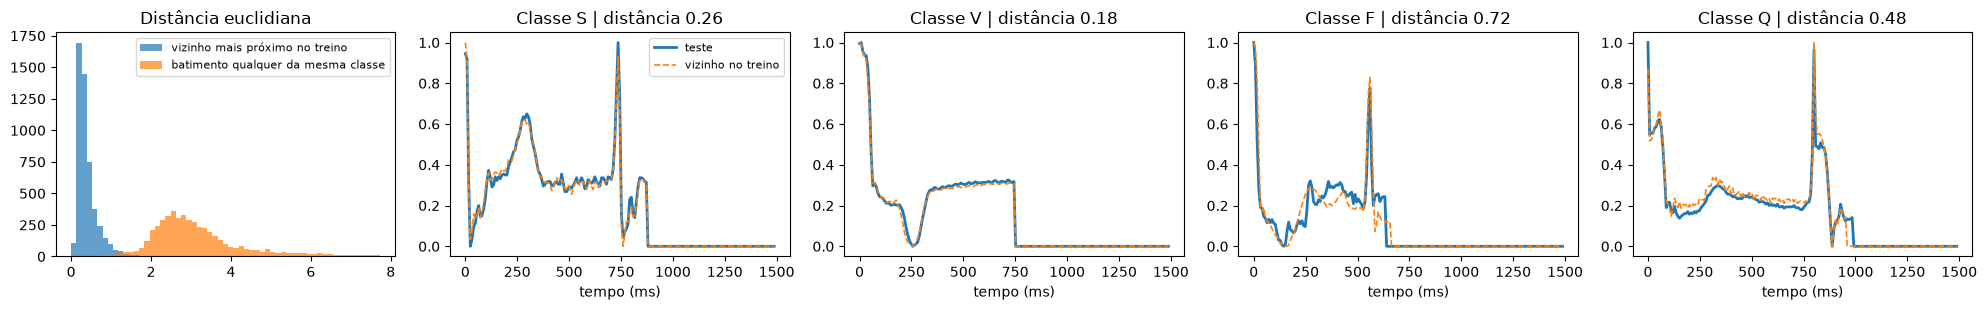

In [23]:
fig, axes = plt.subplots(1, 5, figsize=(20, 3.2))
bins = np.linspace(0, np.percentile(dist_aleatoria, 99), 60)
axes[0].hist(dist_vizinho, bins=bins, alpha=0.7, label="vizinho mais próximo no treino")
axes[0].hist(dist_aleatoria, bins=bins, alpha=0.7, label="batimento qualquer da mesma classe")
axes[0].set_title("Distância euclidiana")
axes[0].legend(fontsize=8)

# Um exemplo de cada classe anormal: batimento de teste e seu vizinho no treino
for ax, c in zip(axes[1:], range(1, N_CLASSES)):
    i = np.flatnonzero(y_amostra == c)[0]
    ax.plot(TEMPO_MS, X_amostra[i], lw=2, label="teste")
    ax.plot(TEMPO_MS, X_treino_total[idx_vizinho[i]], lw=1.2, ls="--", label="vizinho no treino")
    ax.set_title(f"Classe {CLASSES[c]} | distância {dist_vizinho[i]:.2f}")
    ax.set_xlabel("tempo (ms)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "07_vazamento.png", dpi=120)
plt.show()

**Como interpretar.** Se o 1-NN, que só decora, chega perto da CNN e os vizinhos mais próximos estão muito mais perto que um batimento típico da mesma classe, o teste contém quase cópias do treino. Isso **não prova sozinho** que são do mesmo paciente, mas é consistente com a divisão por batimento, e a literatura mostra que, quando a divisão é feita por paciente (divisão DS1/DS2 de de Chazal et al., 2004), o desempenho cai bastante, principalmente na classe S.

**Consequência para a clínica:** os números da seção 7 são **otimistas** para pacientes novos. Antes de uso real, o modelo precisaria ser validado com divisão por paciente e com exames do próprio equipamento da clínica.

## 10. Exemplos de previsões

A função `mostrar_batimento(i)` mostra qualquer batimento do teste com a classe real, a prevista e as probabilidades. Útil para explicar o modelo e para demonstrações ao vivo.

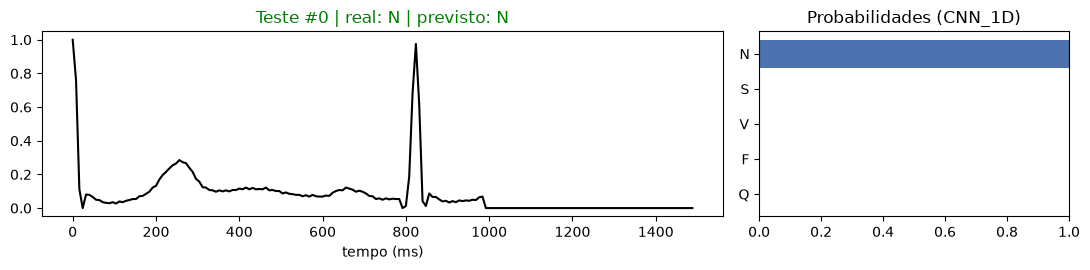

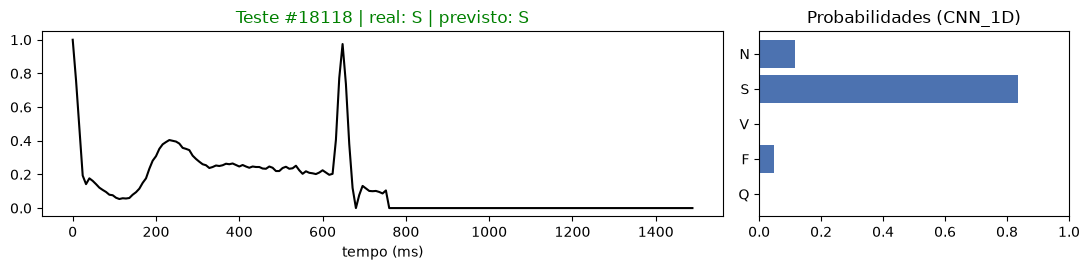

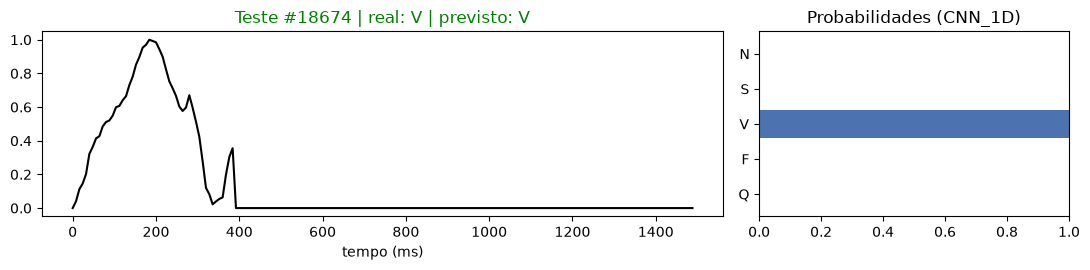

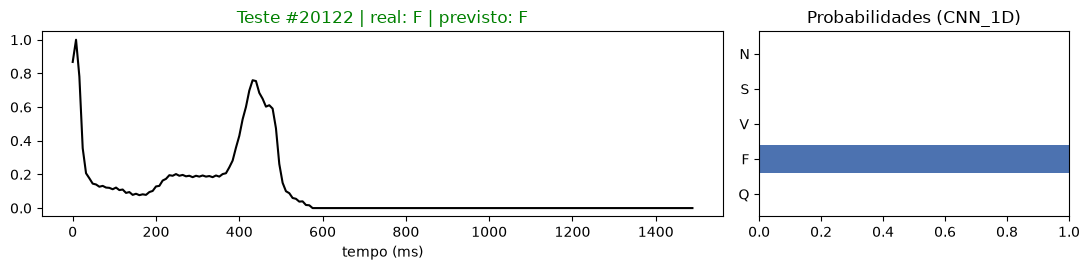

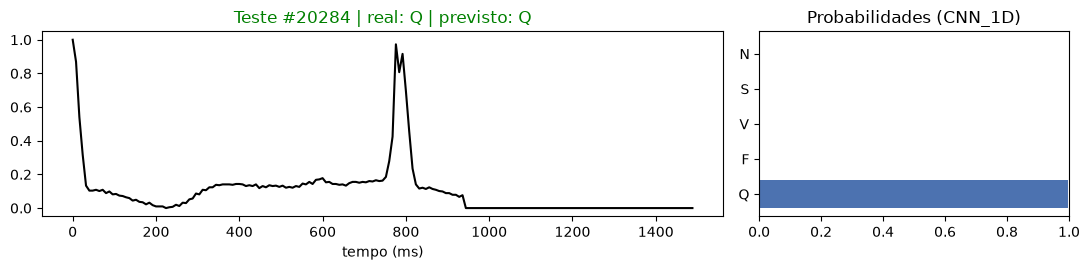

In [24]:
def mostrar_batimento(i, nome_modelo="CNN_1D"):
    probs = resultados[nome_modelo]["probs"][i]
    real, previsto = CLASSES[y_teste[i]], CLASSES[probs.argmax()]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 2.8), gridspec_kw={"width_ratios": [2.2, 1]})
    ax1.plot(TEMPO_MS, X_teste[i], color="black")
    ax1.set_title(f"Teste #{i} | real: {real} | previsto: {previsto}",
                  color="green" if real == previsto else "crimson")
    ax1.set_xlabel("tempo (ms)")
    ax2.barh(CLASSES[::-1], probs[::-1], color="#4C72B0")
    ax2.set_xlim(0, 1)
    ax2.set_title(f"Probabilidades ({nome_modelo})")
    plt.tight_layout()
    plt.show()

# Um acerto de cada classe
for c in range(N_CLASSES):
    acertos = np.flatnonzero((y_teste == c) & (resultados["CNN_1D"]["pred"] == c))
    if len(acertos):
        mostrar_batimento(acertos[0])

Batimentos S classificados como N: 103 de 556


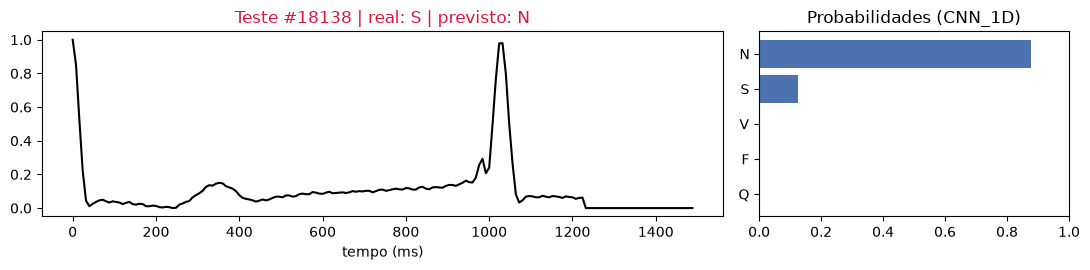

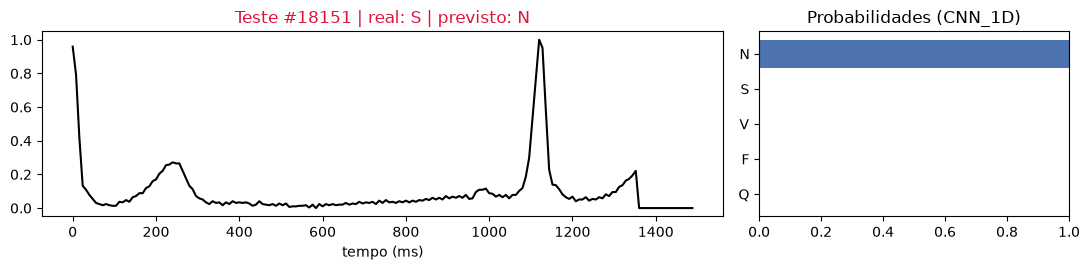

In [25]:
# Erros mais comuns: batimentos S que a CNN classificou como Normal
erros_s = np.flatnonzero((y_teste == 1) & (resultados["CNN_1D"]["pred"] == 0))
print(f"Batimentos S classificados como N: {len(erros_s)} de {int((y_teste == 1).sum())}")
for i in erros_s[:2]:
    mostrar_batimento(i)

## 11. Resumo, limitações e guia de modificações

A célula abaixo junta os números principais (para a ficha técnica e os slides) e salva tudo em `results/metricas.json`.

In [26]:
metricas = {
    "config": CONFIG,
    "teste": {modelo: {k: float(v) for k, v in linha.items()} for modelo, linha in tabela.to_dict(orient="index").items()},
    "triagem_cnn": triagem,
    "vazamento": {k: float(v) for k, v in vazamento.items()},
    "epocas_treinadas": {"MLP": len(hist_mlp["loss"]), "CNN_1D": len(hist_cnn["loss"])},
}
(RESULTS_DIR / f"metricas{SUFIXO}.json").write_text(json.dumps(metricas, indent=2, ensure_ascii=False))

m, c = tabela.loc["MLP"], tabela.loc["CNN_1D"]
print(f"Macro-F1 no teste:  MLP {m['macro-F1']:.3f}  |  CNN 1D {c['macro-F1']:.3f}  |  'sempre Normal' {tabela.loc['Sempre Normal', 'macro-F1']:.3f}")
print(f"Acurácia no teste:  MLP {m['acurácia']:.3f}  |  CNN 1D {c['acurácia']:.3f}")
print("Revocação por classe (CNN 1D): " + ", ".join(f"{k} {c[f'revocação {k}']:.2f}" for k in CLASSES))
print(f"Triagem (CNN 1D, limiar {LIMIAR:.3f}): técnico revisa {triagem['fração revisada']:.1%} dos batimentos "
      f"e o sistema marca {triagem['revocação dos anormais']:.1%} dos anormais")
print(f"Vazamento: 1-NN (só memória) tem macro-F1 {vazamento['1-NN macro-F1']:.3f} "
      f"contra {vazamento['CNN 1D macro-F1 (mesma amostra)']:.3f} da CNN na mesma amostra")

Macro-F1 no teste:  MLP 0.854  |  CNN 1D 0.914  |  'sempre Normal' 0.181
Acurácia no teste:  MLP 0.969  |  CNN 1D 0.984
Revocação por classe (CNN 1D): N 0.99, S 0.80, V 0.96, F 0.86, Q 0.99
Triagem (CNN 1D, limiar 0.015): técnico revisa 25.5% dos batimentos e o sistema marca 98.6% dos anormais
Vazamento: 1-NN (só memória) tem macro-F1 0.889 contra 0.922 da CNN na mesma amostra


### Limitações

- **Divisão por batimento, não por paciente:** os resultados são otimistas para pacientes novos (seção 9).
- **Poucos pacientes e dados antigos:** 47 pessoas, um único hospital, gravações de 1975 a 1979. Não há garantia de desempenho em outros equipamentos, populações ou níveis de ruído.
- **Uma derivação só e batimentos já recortados:** em um Holter real, antes do modelo é preciso detectar os picos R e recortar os batimentos, e erros nessa etapa não foram avaliados aqui.
- **Batimento isolado:** o modelo não vê o ritmo ao redor, o que prejudica a classe S (prematuridade).
- **Triagem, não diagnóstico:** o sistema só indica o que revisar. A decisão é sempre do profissional.

### Guia de modificações ao vivo

| Pedido | Onde mexer |
| --- | --- |
| Mudar kernel, filtros ou número de blocos da CNN | `CONFIG["CNN_KERNEL"]`, `CONFIG["CNN_FILTROS"]` (um item por bloco) |
| Mudar camadas da MLP | `CONFIG["MLP_UNIDADES"]` |
| Dropout, taxa de aprendizado, épocas, paciência, batch | chaves correspondentes no `CONFIG` |
| Mudar ou remover os pesos de classe | `CONFIG["PESO_CLASSES"]` = `"balanceado"`, `"raiz"` ou `"nenhum"` |
| Trocar `GlobalAveragePooling1D` por `Flatten` | função `construir_cnn` (seção 5.2) |
| Mudar a revocação-alvo da triagem | `CONFIG["REVOCACAO_ALVO"]` e rodar a seção 8 |
| Ver um batimento específico | `mostrar_batimento(i)` (seção 10) |
| Demonstração rápida (~1 min) | `CONFIG["MODO_RAPIDO"] = True` |
| Não treinar, só avaliar | `CONFIG["TREINAR"] = False` (usa `results/models`) |